# Notebook 07 — Pythagorean Expectation

The Pythagorean expectation (Bill James, 1980) estimates a team's win percentage from runs scored and runs allowed:

$$\text{Win\%} = \frac{RS^{k}}{RS^{k} + RA^{k}}$$

The original exponent was 2. We use Pythagenpat, which lets the exponent vary by run environment:

$$k = \left(\frac{RS + RA}{G}\right)^{0.287}$$

I also apply a bias correction to the RS/RA estimates from Notebook 06, calibrated on the backtest residuals, to remove the systematic overestimate of wins.

Pipeline: Roster → Run Estimator (NB 06) → Bias Correction → RS/RA → Pythagenpat → Projected Wins

Back-test: Apply to all 30 teams using the estimated RS/RA from Notebook 06, and compare projected wins to actual wins.

In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = os.path.join("..", "data")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

## 1. Pythagorean function

In [40]:
GAMES = 162

def pythagenpat_exp(rs, ra, games=GAMES):
    """Pythagenpat variable exponent based on run environment."""
    rpg = (rs + ra) / games
    return rpg ** 0.287


def pythagorean_win_pct(rs, ra, games=GAMES):
    """Pythagorean win percentage using Pythagenpat exponent."""
    exp = pythagenpat_exp(rs, ra, games)
    rs_k = rs ** exp
    return rs_k / (rs_k + ra ** exp)


def projected_wins(rs, ra, games=GAMES):
    """Projected wins over a season."""
    return round(pythagorean_win_pct(rs, ra, games) * games)


# check
print(f"750 RS / 750 RA → {projected_wins(750, 750)} wins (expect 81)")
print(f"800 RS / 650 RA → {projected_wins(800, 650)} wins")
print(f"600 RS / 800 RA → {projected_wins(600, 800)} wins")
print(f"\nPythagenpat exponents:")
print(f"  750/750 (9.26 RPG): k = {pythagenpat_exp(750, 750):.3f}")
print(f"  800/650 (8.95 RPG): k = {pythagenpat_exp(800, 650):.3f}")
print(f"  600/800 (8.64 RPG): k = {pythagenpat_exp(600, 800):.3f}")

750 RS / 750 RA → 81 wins (expect 81)
800 RS / 650 RA → 97 wins
600 RS / 800 RA → 60 wins

Pythagenpat exponents:
  750/750 (9.26 RPG): k = 1.894
  800/650 (8.95 RPG): k = 1.876
  600/800 (8.64 RPG): k = 1.857


## 2. Load NB 06 back-test data and apply Pythagorean

We reconstruct the back-test table from Notebook 06 (estimated RS/RA and actual RS/RA/wins for all 30 teams) and apply the Pythagorean formula to both the estimated and actual RS/RA.

In [42]:
# Re-run NB06 logic to get the backtest table
import sys, time, requests
sys.path.insert(0, os.path.abspath(".."))

master = pd.read_parquet(os.path.join(DATA, "master_players.parquet"))
park_factors = pd.read_parquet(os.path.join(DATA, "park_factors.parquet"))
hitters = master[master["player_type"] == "hitter"].copy()
pitchers = master[master["player_type"] == "pitcher"].copy()

# Constants from NB06
LG_WOBA = 0.315
WOBA_SCALE = 1.232
LG_R_PER_PA = 0.118
WOBA_REG_PA = 100
UNEARNED_RUN_FACTOR = 1.08
SIERA_WEIGHT, FIP_WEIGHT, ERA_WEIGHT = 0.40, 0.30, 0.30
LG_PITCHER_RATE = 4.10
TEAM_PA_162 = 6000
TEAM_IP_162 = 1458
STARTER_BENCH_SPLIT = 0.85
SP_IP_SHARE = 845 / TEAM_IP_162
RP_IP_SHARE = 1 - SP_IP_SHARE

BASE = "https://statsapi.mlb.com/api/v1"

def _regress(observed, sample_size, lg_mean, k):
    return (sample_size * observed + k * lg_mean) / (sample_size + k)

# --- Estimator functions (from NB06) ---
def estimate_runs_scored(lineup_ids, bench_ids, park_factor=100):
    hl = hitters.set_index("mlbam_id")
    def _get_blended_woba(pid):
        if pid in hl.index:
            row = hl.loc[pid]
            if isinstance(row, pd.DataFrame): row = row.iloc[0]
            woba = row["wOBA"] if pd.notna(row.get("wOBA")) else LG_WOBA
            xwoba = row["xwOBA"] if pd.notna(row.get("xwOBA")) else woba
            pa = float(row["PA"]) if pd.notna(row.get("PA")) else 0
            return 0.5 * _regress(woba, pa, LG_WOBA, WOBA_REG_PA) + \
                   0.5 * _regress(xwoba, pa, LG_WOBA, WOBA_REG_PA)
        return LG_WOBA
    def _get_pa(pid):
        if pid in hl.index:
            pa = hl.loc[pid, "PA"]
            if isinstance(pa, pd.Series): pa = pa.iloc[0]
            if pd.notna(pa): return float(pa)
        return 0.0
    
    starter_pa_total = TEAM_PA_162 * STARTER_BENCH_SPLIT
    starter_actual_pa = [_get_pa(pid) for pid in lineup_ids[:9]]
    total_starter_pa = sum(starter_actual_pa)
    starter_runs = 0.0
    for i, pid in enumerate(lineup_ids[:9]):
        pa_share = starter_actual_pa[i] / total_starter_pa if total_starter_pa > 0 else 1/9
        pa = starter_pa_total * pa_share
        starter_runs += (((_get_blended_woba(pid) - LG_WOBA) / WOBA_SCALE) + LG_R_PER_PA) * pa
    
    bench_pa_total = TEAM_PA_162 * (1 - STARTER_BENCH_SPLIT)
    if bench_ids:
        bench_actual_pa = [_get_pa(pid) for pid in bench_ids]
        total_bench_pa = sum(bench_actual_pa)
        bench_runs = 0.0
        for i, pid in enumerate(bench_ids):
            pa_share = bench_actual_pa[i] / total_bench_pa if total_bench_pa > 0 else 1/len(bench_ids)
            bench_runs += (((_get_blended_woba(pid) - LG_WOBA) / WOBA_SCALE) + LG_R_PER_PA) * bench_pa_total * pa_share
    else:
        bench_runs = LG_R_PER_PA * bench_pa_total
    return round((starter_runs + bench_runs) * ((park_factor / 100 + 1) / 2))

def estimate_runs_allowed(sp_ids, rp_ids, park_factor=100):
    pl = pitchers.set_index("mlbam_id")
    def _rate(pid):
        if pid in pl.index:
            row = pl.loc[pid]
            if isinstance(row, pd.DataFrame): row = row.iloc[0]
            siera = float(row["SIERA"]) if pd.notna(row.get("SIERA")) else None
            fip = None
            for c in ["FIP", "xFIP"]:
                if pd.notna(row.get(c)):
                    fip = float(row[c]); break
            era = float(row["ERA"]) if pd.notna(row.get("ERA")) else None
            tw, bl = 0, 0
            if siera is not None: bl += SIERA_WEIGHT * siera; tw += SIERA_WEIGHT
            if fip is not None: bl += FIP_WEIGHT * fip; tw += FIP_WEIGHT
            if era is not None: bl += ERA_WEIGHT * era; tw += ERA_WEIGHT
            if tw > 0: return bl / tw
        return LG_PITCHER_RATE
    def _ip(pid):
        if pid in pl.index:
            row = pl.loc[pid]
            if isinstance(row, pd.DataFrame): row = row.iloc[0]
            if "IP" in row.index and pd.notna(row["IP"]): return float(row["IP"])
        return 0.0
    
    sp_ip_total = TEAM_IP_162 * SP_IP_SHARE
    sp_actual = [_ip(p) for p in sp_ids]
    tot_sp = sum(sp_actual)
    sp_ra = sum((_rate(p)/9) * sp_ip_total * (sp_actual[i]/tot_sp if tot_sp > 0 else 1/max(len(sp_ids),1))
                for i, p in enumerate(sp_ids))
    
    rp_ip_total = TEAM_IP_162 * RP_IP_SHARE
    rp_actual = [_ip(p) for p in rp_ids]
    tot_rp = sum(rp_actual)
    rp_ra = sum((_rate(p)/9) * rp_ip_total * (rp_actual[i]/tot_rp if tot_rp > 0 else 1/max(len(rp_ids),1))
                for i, p in enumerate(rp_ids))
    
    return round((sp_ra + rp_ra) * UNEARNED_RUN_FACTOR * ((park_factor / 100 + 1) / 2))

# --- Team name to park factor mapping ---
pf_map = {r["team"].strip(): r["park_factor_5yr"] for _, r in park_factors.iterrows()}
TEAM_TO_PF = {
    "Los Angeles Angels": "Angels", "Arizona Diamondbacks": "Diamondbacks",
    "Baltimore Orioles": "Orioles", "Boston Red Sox": "Red Sox",
    "Chicago Cubs": "Cubs", "Cincinnati Reds": "Reds",
    "Cleveland Guardians": "Guardians", "Colorado Rockies": "Rockies",
    "Detroit Tigers": "Tigers", "Houston Astros": "Astros",
    "Kansas City Royals": "Royals", "Los Angeles Dodgers": "Dodgers",
    "Washington Nationals": "Nationals", "New York Mets": "Mets",
    "Oakland Athletics": "Athletics", "Athletics": "Athletics",
    "Pittsburgh Pirates": "Pirates",
    "San Diego Padres": "Padres", "Seattle Mariners": "Mariners",
    "San Francisco Giants": "Giants", "St. Louis Cardinals": "Cardinals",
    "Tampa Bay Rays": "Rays", "Texas Rangers": "Rangers",
    "Toronto Blue Jays": "Blue Jays", "Minnesota Twins": "Twins",
    "Philadelphia Phillies": "Phillies", "Atlanta Braves": "Braves",
    "Chicago White Sox": "White Sox", "Miami Marlins": "Marlins",
    "New York Yankees": "Yankees", "Milwaukee Brewers": "Brewers",
}

def get_park_factor(team_name):
    return pf_map.get(TEAM_TO_PF.get(team_name, ""), 100)

# fetch standings for actuals
teams_resp = requests.get(f"{BASE}/teams?sportId=1&season=2025", timeout=30)
team_id_to_name = {t["id"]: t["name"] for t in teams_resp.json()["teams"]}

time.sleep(0.5)
standings_resp = requests.get(f"{BASE}/standings?leagueId=103,104&season=2025&standingsTypes=regularSeason", timeout=30)
actual = {}
for div in standings_resp.json()["records"]:
    for t in div["teamRecords"]:
        tid = t["team"]["id"]
        full_name = team_id_to_name.get(tid, t["team"]["name"])
        actual[full_name] = {
            "RS_actual": t["runsScored"], "RA_actual": t["runsAllowed"], "wins_actual": t["wins"]
        }

# build rosters from master table (same as NB06)
all_team_names = master["team"].unique()
results = []
for tname in sorted(all_team_names):
    team_h = hitters[hitters["team"] == tname].sort_values("PA", ascending=False)
    lineup = team_h["mlbam_id"].tolist()[:9]
    bench = team_h["mlbam_id"].tolist()[9:13]
    
    team_p = pitchers[pitchers["team"] == tname].sort_values(["GS", "IP"], ascending=False)
    sp = team_p.head(5)["mlbam_id"].tolist()
    remaining = team_p.iloc[5:]
    rp = remaining[remaining["IP"] > 0].head(8)["mlbam_id"].tolist()
    if not rp: rp = remaining.head(8)["mlbam_id"].tolist()
    
    pf = get_park_factor(tname)
    a = actual.get(tname, {})
    results.append({
        "team": tname, "park_factor": pf,
        "RS_est": estimate_runs_scored(lineup, bench, pf),
        "RA_est": estimate_runs_allowed(sp, rp, pf),
        **a
    })

backtest = pd.DataFrame(results)
print(f"Backtest table rebuilt: {backtest.shape}")
backtest.head(3)

Backtest table rebuilt: (30, 7)


,team,park_factor,RS_est,RA_est,RS_actual,RA_actual,wins_actual
0,Arizona Diamondbacks,101,803,731,791,785,80
1,Athletics,103,772,801,733,817,76
2,Atlanta Braves,100,747,719,724,734,76


## 3. Bias correction and Pythagenpat projection

The run estimator from NB 06 has a systematic bias: it tends to overestimate RS and underestimate RA.
We compute per-team RS/RA residuals and apply a simple multiplicative correction factor to recalibrate.

In [44]:
# step 1: Compute bias correction factors from backtest
rs_ratio = backtest["RS_actual"].mean() / backtest["RS_est"].mean()
ra_ratio = backtest["RA_actual"].mean() / backtest["RA_est"].mean()
print(f"Bias correction factors:  RS × {rs_ratio:.4f},  RA × {ra_ratio:.4f}")
print(f"  (RS_est avg: {backtest['RS_est'].mean():.0f} → actual avg: {backtest['RS_actual'].mean():.0f})")
print(f"  (RA_est avg: {backtest['RA_est'].mean():.0f} → actual avg: {backtest['RA_actual'].mean():.0f})")

# correction
backtest["RS_corr"] = (backtest["RS_est"] * rs_ratio).round().astype(int)
backtest["RA_corr"] = (backtest["RA_est"] * ra_ratio).round().astype(int)

# step 2: Uncorrected projections (Pythagenpat, no bias fix)
backtest["wins_proj_raw"] = backtest.apply(
    lambda r: projected_wins(r["RS_est"], r["RA_est"]), axis=1
)

# step 3: Corrected projections (Pythagenpat + bias correction) 
backtest["wins_proj"] = backtest.apply(
    lambda r: projected_wins(r["RS_corr"], r["RA_corr"]), axis=1
)
backtest["win_pct_proj"] = backtest.apply(
    lambda r: round(pythagorean_win_pct(r["RS_corr"], r["RA_corr"]), 3), axis=1
)

# pythagorean wins from ACTUAL RS/RA (ceiling)
backtest["wins_pyth_actual"] = backtest.apply(
    lambda r: projected_wins(r["RS_actual"], r["RA_actual"]), axis=1
)

# residuals
backtest["wins_diff"] = backtest["wins_proj"] - backtest["wins_actual"]
backtest["wins_diff_raw"] = backtest["wins_proj_raw"] - backtest["wins_actual"]
backtest["pyth_actual_diff"] = backtest["wins_pyth_actual"] - backtest["wins_actual"]

print(f"\n{'team':<28} {'RS_est':>6} {'RS_cor':>6} {'RA_est':>6} {'RA_cor':>6} "
      f"{'W_raw':>5} {'W_proj':>6} {'W_act':>5} {'diff':>5}")
print("-" * 95)
for _, row in backtest.sort_values("wins_proj", ascending=False).iterrows():
    short = row["team"]
    print(f"{short:<28} {row['RS_est']:>6} {row['RS_corr']:>6} {row['RA_est']:>6} {row['RA_corr']:>6} "
          f"{row['wins_proj_raw']:>5} {row['wins_proj']:>6} {row['wins_actual']:>5} {row['wins_diff']:>+5}")

Bias correction factors:  RS × 0.9825,  RA × 1.0060
  (RS_est avg: 733 → actual avg: 720)
  (RA_est avg: 716 → actual avg: 720)

team                         RS_est RS_cor RA_est RA_cor W_raw W_proj W_act  diff
-----------------------------------------------------------------------------------------------
Los Angeles Dodgers             807    793    657    661    96     95    93    +2
New York Yankees                821    807    687    691    95     93    94    -1
Philadelphia Phillies           778    764    657    661    94     92    96    -4
Seattle Mariners                743    730    631    635    93     91    90    +1
Milwaukee Brewers               730    717    632    636    92     90    97    -7
Chicago Cubs                    768    755    671    675    91     89    92    -3
Toronto Blue Jays               795    781    704    708    90     88    94    -6
New York Mets                   794    780    707    711    90     88    83    +5
Detroit Tigers                  744  

## 4. Error metrics

In [46]:
# uncorrected (Pythagenpat only, no bias fix)
raw_rmse = np.sqrt((backtest["wins_diff_raw"] ** 2).mean())
raw_mae = backtest["wins_diff_raw"].abs().mean()
raw_corr = backtest["wins_proj_raw"].corr(backtest["wins_actual"])
raw_bias = backtest["wins_diff_raw"].mean()

# corrected (Pythagenpat + bias correction) 
proj_rmse = np.sqrt((backtest["wins_diff"] ** 2).mean())
proj_mae = backtest["wins_diff"].abs().mean()
proj_corr = backtest["wins_proj"].corr(backtest["wins_actual"])
proj_bias = backtest["wins_diff"].mean()

# pythagorean ceiling (actual RS/RA) 
pyth_rmse = np.sqrt((backtest["pyth_actual_diff"] ** 2).mean())
pyth_mae = backtest["pyth_actual_diff"].abs().mean()
pyth_corr = backtest["wins_pyth_actual"].corr(backtest["wins_actual"])

print("=" * 75)
print(f"{'Metric':<22} {'Raw (no fix)':>13} {'Corrected':>13} {'Pyth(actual)':>14}")
print("=" * 75)
print(f"{'RMSE (wins)':<22} {raw_rmse:>13.1f} {proj_rmse:>13.1f} {pyth_rmse:>14.1f}")
print(f"{'MAE (wins)':<22} {raw_mae:>13.1f} {proj_mae:>13.1f} {pyth_mae:>14.1f}")
print(f"{'Correlation':<22} {raw_corr:>13.3f} {proj_corr:>13.3f} {pyth_corr:>14.3f}")
print(f"{'Mean bias':<22} {raw_bias:>+13.1f} {proj_bias:>+13.1f} {'--':>14}")
print("=" * 75)
print(f"\nImprovements from bias correction:")
print(f"  RMSE: {raw_rmse:.1f} → {proj_rmse:.1f} ({raw_rmse - proj_rmse:+.1f} wins)")
print(f"  MAE:  {raw_mae:.1f} → {proj_mae:.1f} ({raw_mae - proj_mae:+.1f} wins)")
print(f"  Bias: {raw_bias:+.1f} → {proj_bias:+.1f}")

Metric                  Raw (no fix)     Corrected   Pyth(actual)
RMSE (wins)                      6.1           5.7            4.7
MAE (wins)                       4.8           4.7            3.8
Correlation                    0.871         0.874          0.925
Mean bias                       +2.0          +0.1             --

Improvements from bias correction:
  RMSE: 6.1 → 5.7 (+0.4 wins)
  MAE:  4.8 → 4.7 (+0.1 wins)
  Bias: +2.0 → +0.1


## 5. Back-test scatter plot

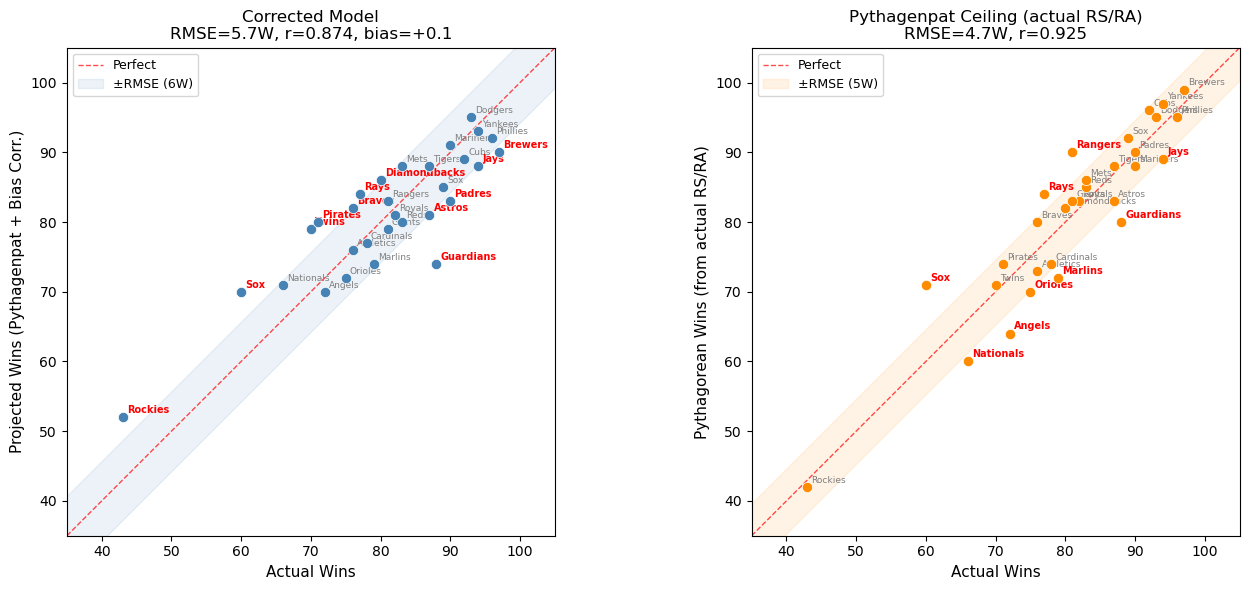

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# panel 1: Our corrected projected wins vs actual
ax = axes[0]
ax.scatter(backtest["wins_actual"], backtest["wins_proj"], s=55, c="steelblue",
           edgecolors="white", linewidths=0.5, zorder=5)

for _, row in backtest.iterrows():
    short = row["team"].split()[-1]
    offset_x, offset_y = 3, 3
    if abs(row["wins_diff"]) > proj_rmse:
        ax.annotate(short, (row["wins_actual"], row["wins_proj"]),
                   fontsize=7, fontweight="bold", color="red",
                   xytext=(offset_x, offset_y), textcoords="offset points")
    else:
        ax.annotate(short, (row["wins_actual"], row["wins_proj"]),
                   fontsize=6.5, color="gray",
                   xytext=(offset_x, offset_y), textcoords="offset points")

lims = [35, 105]
ax.plot(lims, lims, "r--", linewidth=1, alpha=0.7, label="Perfect")
ax.fill_between(lims, [l - proj_rmse for l in lims], [l + proj_rmse for l in lims],
                alpha=0.1, color="steelblue", label=f"±RMSE ({proj_rmse:.0f}W)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual Wins", fontsize=11)
ax.set_ylabel("Projected Wins (Pythagenpat + Bias Corr.)", fontsize=11)
ax.set_title(f"Corrected Model\nRMSE={proj_rmse:.1f}W, r={proj_corr:.3f}, bias={proj_bias:+.1f}", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.set_aspect("equal")

# panel 2: pythagorean ceiling
ax = axes[1]
ax.scatter(backtest["wins_actual"], backtest["wins_pyth_actual"], s=55, c="darkorange",
           edgecolors="white", linewidths=0.5, zorder=5)

for _, row in backtest.iterrows():
    short = row["team"].split()[-1]
    if abs(row["pyth_actual_diff"]) > pyth_rmse:
        ax.annotate(short, (row["wins_actual"], row["wins_pyth_actual"]),
                   fontsize=7, fontweight="bold", color="red",
                   xytext=(3, 3), textcoords="offset points")
    else:
        ax.annotate(short, (row["wins_actual"], row["wins_pyth_actual"]),
                   fontsize=6.5, color="gray",
                   xytext=(3, 3), textcoords="offset points")

ax.plot(lims, lims, "r--", linewidth=1, alpha=0.7, label="Perfect")
ax.fill_between(lims, [l - pyth_rmse for l in lims], [l + pyth_rmse for l in lims],
                alpha=0.1, color="darkorange", label=f"±RMSE ({pyth_rmse:.0f}W)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual Wins", fontsize=11)
ax.set_ylabel("Pythagorean Wins (from actual RS/RA)", fontsize=11)
ax.set_title(f"Pythagenpat Ceiling (actual RS/RA)\nRMSE={pyth_rmse:.1f}W, r={pyth_corr:.3f}", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()